In [63]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from langchain.messages import SystemMessage,HumanMessage
from typing import TypedDict,Literal,Annotated
from pydantic import BaseModel,Field
import operator

In [64]:
llm = ChatOllama(model="llama3.2:3b", temperature=0.1,format="json")

In [65]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["Approved", "Needs_Improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

structured_evaluator_llm = llm.with_structured_output(TweetEvaluation)

In [66]:
class PostState(TypedDict):

    topic:str
    post:str
    evaluation:Literal['Approved','Needs_Improvement']
    feedback:str
    iteration:int
    #sometimes llm goes into loop as some llms are not most capable of genration,evalution and optimizing that why it can go into loop
    max_iteration:int

    post_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]

In [67]:
def Generate_post(state:PostState):

    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
            ]
    
    response = llm.invoke(messages).content
    return {'post':response,'post_history':[response]}

def Evaluate_post(state:PostState):

    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['post']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
        ]
    
    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation,'feedback':response.feedback,'feedback_history':[response.feedback]}

def Optimizer_post(state:PostState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the tweet based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"
            Original Tweet:
            {state['post']}

            Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
            """)
                ]
    response = llm.invoke(messages).content
    iteration = state['iteration']+1

    return {'post':response,'iteration':iteration,'post_history':[response]}

def Check_Post(state:PostState):

    if state['evaluation']=="Approved" or state['iteration'] >= state['max_iteration']:
        return 'Approved'
    else:
        return "Needs_Improvement"

In [ ]:
graph = StateGraph(PostState)

graph.add_node("Generate_post",Generate_post)
graph.add_node("Evaluate_post",Evaluate_post)
graph.add_node("Optimizer_post",Optimizer_post)

graph.add_edge(START,'Generate_post')
graph.add_edge('Generate_post',"Evaluate_post")
graph.add_conditional_edges('Evaluate_post',Check_Post,{'Approved':END,'Needs_Improvement':"Optimizer_post"})
graph.add_edge("Optimizer_post",'Evaluate_post')

workflow = graph.compile()

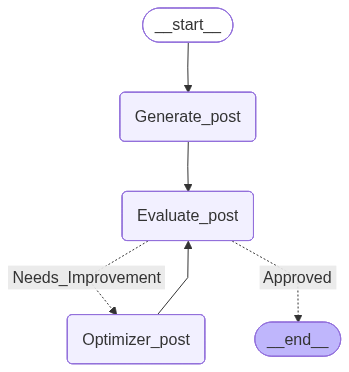

In [69]:
workflow

In [70]:
initial_state = {
    "topic": "black man",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)
result

{'topic': 'black man',
 'post': '{"Just walked into a meeting & everyone\'s like \'great, another [insert demographic here]\' Guess I\'m just that relatable #sameproblemeverywhere":-3}',
 'evaluation': 'Approved',
 'feedback': "This tweet is a great example of concise humor. The use of '[insert demographic here]' as a punchline is unexpected, making it relatable and funny. The format is well-structured, and the hashtags (#sameproblemeverywhere) add to the tweet's originality. However, some might find the tone slightly sarcastic or ironic, which could be off-putting for those who don't catch the humor. Overall, this tweet effectively uses wordplay and social commentary to create a humorous effect.",
 'iteration': 2,
 'max_iteration': 5,
 'post_history': ['{"I just saw a black man walk into a room and everyone was like \'oh, great, another black person\' #blackmanprobs":-3}',
  '{"Just walked into a meeting & everyone\'s like \'great, another [insert demographic here]\' Guess I\'m just t

In [71]:
for tweet in result['post_history']:
    print(tweet)

{"I just saw a black man walk into a room and everyone was like 'oh, great, another black person' #blackmanprobs":-3}
{"Just walked into a meeting & everyone's like 'great, another [insert demographic here]' Guess I'm just that relatable #sameproblemeverywhere":-3}
